# BirdCLEF 2026: CV + Pseudo-Label + Ensemble Audio Pipeline

This notebook is the most complete experiment pipeline in this project. It implements:

- Stage 1 full `train_audio` training.
- Stage 2 soundscape fine-tuning.
- Stage 3 pseudo-labeling from unlabeled `train_soundscapes`.
- A stronger `torchvision` EfficientNet backbone.
- grouped CV by soundscape file or site.
- multiple folds.
- ensemble inference by averaging logits.
- CPU/GPU-aware inference and optional Kaggle-style `submission.csv` creation.

There are no helper scripts. Everything is inside this notebook.

**Important:** this is an experimental project notebook. Results depend on training quality, fold stability, pseudo-label thresholds, and iteration.

## 0. Imports and Hardware

In [21]:
from pathlib import Path
import ast
import gc
import hashlib
import json
import math
import os
import platform
import random
import re
import subprocess
import sys
import time
import warnings

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from IPython.display import display

try:
    import torchvision
    from torchvision import models
except Exception as exc:
    raise ModuleNotFoundError("This notebook needs torchvision for EfficientNet.") from exc

try:
    from sklearn.model_selection import GroupKFold, StratifiedKFold
except Exception as exc:
    raise ModuleNotFoundError("This notebook needs scikit-learn for CV folds.") from exc

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is required for this notebook. Enable a GPU runtime or install CUDA-enabled PyTorch before training.")
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda")
USE_AMP = True

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Selected device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))
print("CUDA used by PyTorch:", torch.version.cuda)
print("VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))

try:
    smi = subprocess.run(["nvidia-smi"], capture_output=True, text=True, timeout=10)
    if smi.returncode == 0:
        print("\n".join(smi.stdout.splitlines()[:14]))
except Exception:
    pass

Python: 3.11.4
Platform: Windows-10-10.0.19045-SP0
Torch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA available: True
Selected device: cuda
GPU: NVIDIA GeForce RTX 3060
CUDA used by PyTorch: 12.8
VRAM GB: 12.0
Wed Jun  3 00:12:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 596.49                 Driver Version: 596.49         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060      WDDM  |   00000000:01:00.0  On |                  N/A |
| 34%   54C    P5     

## 1. Configuration

The full run is intentionally behind `RUN_FULL_TRAINING`. Set it to `True` when you are ready for a long run.

In [22]:
PROJECT_DIR = Path.cwd()
WORK_DIR = PROJECT_DIR / "birdclef_work"
STRONG_DIR = WORK_DIR / "strong_pipeline"
CHECKPOINT_DIR = STRONG_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

def looks_like_birdclef_dataset(path):
    required = ["taxonomy.csv", "sample_submission.csv", "train.csv", "train_audio", "train_soundscapes", "test_soundscapes"]
    return path.exists() and path.is_dir() and all((path / item).exists() for item in required)

def find_dataset_dir():
    candidates = []
    env_dir = os.environ.get("BIRDCLEF_DATA_DIR")
    if env_dir:
        candidates.append(Path(env_dir))
    for base in [PROJECT_DIR, PROJECT_DIR.parent, Path("/kaggle/input")]:
        candidates.extend([base / "birdclef-2026", base / "birdcle-2026"])
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        candidates.extend([p for p in kaggle_input.iterdir() if p.is_dir()])
    for candidate in candidates:
        if looks_like_birdclef_dataset(candidate):
            return candidate.resolve()
    raise FileNotFoundError("Could not find BirdCLEF dataset folder.")

DATA_DIR = find_dataset_dir()
TEST_DIR = DATA_DIR / "test_soundscapes"

# Main switches.
RUN_SMOKE_TEST = True
RUN_FULL_TRAINING = False
RUN_SUBMISSION_INFERENCE = True
RESUME_IF_CHECKPOINT_EXISTS = True

# Stages. Start practical: Stage 1 + Stage 2. Enable Stage 3 after checking Stage 2 validation.
RUN_STAGE1 = True
RUN_STAGE2 = True
RUN_STAGE3 = True 

# CV / ensemble settings.
N_FOLDS = 5
# Start with one fold. Full 5-fold training is much slower: set [0, 1, 2, 3, 4] only for a final run.
TRAIN_FOLDS = [0, 1, 2]
SOUNDSCAPE_GROUP_MODE = "filename"  # options: "filename" or "site"

# Model settings.
MODEL_NAME = "efficientnet_b0"
USE_IMAGENET_PRETRAINED = True
DROPOUT = 0.25

# Audio settings.
TARGET_SR = 32_000
CLIP_SECONDS = 5
CLIP_SAMPLES = TARGET_SR * CLIP_SECONDS
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
FMIN = 20
FMAX = TARGET_SR // 2

# Training settings. Tune after the first complete local validation run.
STAGE1_EPOCHS = 6
STAGE2_EPOCHS = 20
STAGE3_EPOCHS = 6
STAGE1_LR = 2e-4
STAGE2_LR = 8e-5
STAGE3_LR = 5e-5
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 5.0

BATCH_SIZE_STAGE1 = 40
BATCH_SIZE_STAGE2 = 32
BATCH_SIZE_INFER_GPU = 64
NUM_WORKERS = 0  # safest for Windows notebooks

# Pseudo-label settings. Start smaller, then increase after checking pseudo labels.
PSEUDO_MAX_FILES = 1200
PSEUDO_THRESHOLD = 0.82
PSEUDO_TOP_K = 5
PSEUDO_MIN_ROWS = 100

# CPU speed-up: cache log-mel spectrograms as .npy files.
# Soundscape cache is small and useful. Full train_audio cache is larger, so enable it when you have disk space.
USE_LOGMEL_CACHE = True
BUILD_CACHE_IF_MISSING = True
CACHE_SOUNDSCAPE_WINDOWS = True
CACHE_TRAIN_AUDIO = False
CACHE_TRAIN_AUDIO_MAX_ROWS = None  # set e.g. 5000 for a quick partial cache test
CACHE_DTYPE = np.float16
CACHE_DIR = STRONG_DIR / "logmel_cache"
TRAIN_AUDIO_CACHE_DIR = CACHE_DIR / "train_audio"
SOUNDSCAPE_CACHE_DIR = CACHE_DIR / "soundscape_windows"
PSEUDO_CACHE_DIR = CACHE_DIR / "pseudo_windows"

# Inference stays on CUDA for the full pipeline.
FORCE_CPU_INFERENCE = False
SUBMISSION_PATH = PROJECT_DIR / "submission.csv"

print("Dataset:", DATA_DIR)
print("Strong pipeline dir:", STRONG_DIR)
print("Checkpoint dir:", CHECKPOINT_DIR)
print("RUN_FULL_TRAINING:", RUN_FULL_TRAINING)
print("TRAIN_FOLDS:", TRAIN_FOLDS)

Dataset: D:\BirdCLEF+\birdclef-2026
Strong pipeline dir: d:\BirdCLEF+\birdclef_work\strong_pipeline
Checkpoint dir: d:\BirdCLEF+\birdclef_work\strong_pipeline\checkpoints
RUN_FULL_TRAINING: False
TRAIN_FOLDS: [0, 1, 2]


## 2. Load Metadata and Targets

In [23]:
label_map_path = WORK_DIR / "label_map.csv"
train_audio_manifest_path = WORK_DIR / "train_audio_manifest.csv"
soundscape_windows_path = WORK_DIR / "train_soundscape_windows.csv"

for path in [label_map_path, train_audio_manifest_path, soundscape_windows_path]:
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run notebook 01 first.")

label_map = pd.read_csv(label_map_path, dtype={"primary_label": str})
target_labels = label_map["primary_label"].astype(str).tolist()
label_to_index = {label: i for i, label in enumerate(target_labels)}
num_classes = len(target_labels)

train_audio = pd.read_csv(train_audio_manifest_path, dtype={"primary_label": str})
train_audio = train_audio[train_audio["file_exists"].astype(str).str.lower().eq("true")].reset_index(drop=True)
train_audio["audio_path"] = train_audio["audio_path"].astype(str)
train_audio["labels_string"] = train_audio["labels_string"].astype(str)

soundscape_df = pd.read_csv(soundscape_windows_path, dtype={"filename": str})
soundscape_df = soundscape_df[soundscape_df["file_exists"].astype(str).str.lower().eq("true")].reset_index(drop=True)
soundscape_df["audio_path"] = soundscape_df["audio_path"].astype(str)
soundscape_df["start_seconds"] = soundscape_df["start_seconds"].astype(float)
soundscape_df[target_labels] = soundscape_df[target_labels].astype(np.float32)

sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")
if [c for c in sample_submission.columns if c != "row_id"] != target_labels:
    raise ValueError("sample_submission columns do not match label_map target order.")

def parse_label_string(value):
    if pd.isna(value):
        return []
    text = str(value).strip()
    if text in {"", "nan", "[]"}:
        return []
    return [x for x in text.split(";") if x in label_to_index]

def labels_to_multihot(labels, soft_values=None):
    y = np.zeros(num_classes, dtype=np.float32)
    if soft_values is None:
        for label in labels:
            if label in label_to_index:
                y[label_to_index[label]] = 1.0
    else:
        for label, value in zip(labels, soft_values):
            if label in label_to_index:
                y[label_to_index[label]] = float(value)
    return y

def extract_site(filename):
    match = re.search(r"_S(\d+)_", str(filename))
    return f"S{match.group(1)}" if match else "unknown"

soundscape_df["site"] = soundscape_df["filename"].apply(extract_site)

print("Targets:", num_classes)
print("Train audio clips:", len(train_audio), "primary labels:", train_audio["primary_label"].nunique())
print("Labeled soundscape windows:", len(soundscape_df), "files:", soundscape_df["filename"].nunique(), "sites:", soundscape_df["site"].nunique())
print("Soundscape positive classes:", int((soundscape_df[target_labels].sum(axis=0) > 0).sum()))

Targets: 234
Train audio clips: 35549 primary labels: 206
Labeled soundscape windows: 1478 files: 66 sites: 9
Soundscape positive classes: 75


## 3. CV Folds

`train_audio` uses a rare-label-safe stratified fold assignment. Soundscapes use grouped folds by file or site.

In [24]:
def assign_train_audio_folds(df, n_folds=N_FOLDS):
    df = df.copy().reset_index(drop=True)
    df["fold"] = -1
    counts = df["primary_label"].value_counts()
    common_labels = set(counts[counts >= n_folds].index)
    common_idx = df.index[df["primary_label"].isin(common_labels)].to_numpy().copy()
    rare_idx = df.index[~df["primary_label"].isin(common_labels)].to_numpy().copy()

    if len(common_idx) > 0:
        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
        y = df.loc[common_idx, "primary_label"].values
        for fold, (_, val_pos) in enumerate(skf.split(common_idx, y)):
            df.loc[common_idx[val_pos], "fold"] = fold

    rng = np.random.default_rng(SEED)
    rng.shuffle(rare_idx)
    for i, idx in enumerate(rare_idx):
        df.loc[idx, "fold"] = i % n_folds

    assert (df["fold"] >= 0).all()
    return df

def assign_soundscape_folds(df, n_folds=N_FOLDS, group_mode=SOUNDSCAPE_GROUP_MODE):
    df = df.copy().reset_index(drop=True)
    group_col = "site" if group_mode == "site" else "filename"
    groups = df[group_col].values
    actual_folds = min(n_folds, df[group_col].nunique())
    gkf = GroupKFold(n_splits=actual_folds)
    df["fold"] = -1
    dummy_y = np.zeros(len(df))
    for fold, (_, val_idx) in enumerate(gkf.split(df, dummy_y, groups=groups)):
        df.loc[val_idx, "fold"] = fold
    assert (df["fold"] >= 0).all()
    return df, group_col, actual_folds

train_audio_folds = assign_train_audio_folds(train_audio)
soundscape_folds, soundscape_group_col, actual_soundscape_folds = assign_soundscape_folds(soundscape_df)

train_audio_folds.to_csv(STRONG_DIR / "train_audio_folds.csv", index=False)
soundscape_folds.to_csv(STRONG_DIR / "soundscape_folds.csv", index=False)

print("Train audio fold counts:")
display(train_audio_folds["fold"].value_counts().sort_index())
print("Soundscape fold counts grouped by", soundscape_group_col)
display(soundscape_folds["fold"].value_counts().sort_index())

Train audio fold counts:


fold
0    7111
1    7111
2    7109
3    7109
4    7109
Name: count, dtype: int64

Soundscape fold counts grouped by filename


fold
0    298
1    294
2    296
3    292
4    298
Name: count, dtype: int64

## 4. Audio Backend and Spectrograms

In [25]:
AUDIO_BACKEND = None
try:
    import librosa
    AUDIO_BACKEND = "librosa"
    print("Audio backend: librosa", librosa.__version__)
except Exception:
    librosa = None
    try:
        import torchaudio
        AUDIO_BACKEND = "torchaudio"
        print("Audio backend: torchaudio", torchaudio.__version__)
    except Exception as exc:
        raise ModuleNotFoundError("Install librosa+soundfile or torchaudio to read .ogg audio.") from exc

def pad_or_trim(y, target_len=CLIP_SAMPLES):
    y = np.asarray(y, dtype=np.float32)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    elif len(y) > target_len:
        y = y[:target_len]
    return y

def load_audio(path, offset_seconds=0.0, duration_seconds=CLIP_SECONDS, target_sr=TARGET_SR):
    path = Path(path)
    if AUDIO_BACKEND == "librosa":
        y, _ = librosa.load(path, sr=target_sr, mono=True, offset=float(offset_seconds), duration=float(duration_seconds))
        return pad_or_trim(y, int(target_sr * duration_seconds))
    waveform, sr = torchaudio.load(str(path))
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    start = int(round(float(offset_seconds) * sr))
    end = start + int(round(float(duration_seconds) * sr))
    waveform = waveform[:, start:end]
    if sr != target_sr:
        waveform = torchaudio.functional.resample(waveform, sr, target_sr)
    return pad_or_trim(waveform.squeeze(0).numpy(), int(target_sr * duration_seconds))

def get_audio_duration(path):
    path = Path(path)
    if AUDIO_BACKEND == "librosa":
        return float(librosa.get_duration(path=str(path)))
    info = torchaudio.info(str(path))
    return float(info.num_frames / info.sample_rate)

if AUDIO_BACKEND == "torchaudio":
    MEL_TRANSFORM = torchaudio.transforms.MelSpectrogram(sample_rate=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS, f_min=FMIN, f_max=FMAX, power=2.0)
    DB_TRANSFORM = torchaudio.transforms.AmplitudeToDB(stype="power")

def waveform_to_logmel(y):
    y = np.asarray(y, dtype=np.float32)
    if AUDIO_BACKEND == "librosa":
        mel = librosa.feature.melspectrogram(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS, fmin=FMIN, fmax=FMAX, power=2.0)
        logmel = librosa.power_to_db(mel, ref=np.max)
    else:
        waveform = torch.tensor(y, dtype=torch.float32).unsqueeze(0)
        logmel = DB_TRANSFORM(MEL_TRANSFORM(waveform)).squeeze(0).numpy()
    mean = float(logmel.mean())
    std = float(logmel.std())
    return ((logmel - mean) / (std + 1e-6)).astype(np.float32)

def augment_waveform(y):
    y = y.astype(np.float32)
    if np.random.rand() < 0.7:
        y = y * np.random.uniform(0.70, 1.35)
    if np.random.rand() < 0.35:
        y = y + np.random.normal(0, np.random.uniform(0.001, 0.006), size=y.shape).astype(np.float32)
    if np.random.rand() < 0.25:
        y = np.roll(y, np.random.randint(-TARGET_SR // 2, TARGET_SR // 2))
    return np.clip(y, -1.0, 1.0).astype(np.float32)

def spec_augment(x):
    x = x.copy()
    if np.random.rand() < 0.50:
        f = np.random.randint(0, max(1, N_MELS // 12))
        f0 = np.random.randint(0, max(1, N_MELS - f))
        x[f0:f0 + f, :] = 0
    if np.random.rand() < 0.50:
        t = np.random.randint(0, max(1, x.shape[1] // 12))
        t0 = np.random.randint(0, max(1, x.shape[1] - t))
        x[:, t0:t0 + t] = 0
    return x

def to_three_channel(logmel):
    return np.repeat(logmel[None, :, :], 3, axis=0).astype(np.float32)

def seconds_to_hhmmss(seconds):
    seconds = int(round(float(seconds)))
    return f"{seconds // 3600:02d}:{(seconds % 3600) // 60:02d}:{seconds % 60:02d}"

def logmel_cache_path(cache_dir, audio_path, start_seconds=0.0):
    key = f"{Path(audio_path).as_posix()}|{float(start_seconds):.3f}|{TARGET_SR}|{N_MELS}|{HOP_LENGTH}|{N_FFT}"
    digest = hashlib.sha1(key.encode("utf-8")).hexdigest()
    return Path(cache_dir) / f"{digest}.npy"

def add_cache_paths(df, cache_dir):
    df = df.copy()
    starts = df["start_seconds"].astype(float).values if "start_seconds" in df.columns else np.zeros(len(df), dtype=np.float32)
    df["cache_path"] = [str(logmel_cache_path(cache_dir, path, start)) for path, start in zip(df["audio_path"].astype(str).values, starts)]
    return df

def build_logmel_cache(df, cache_dir, label="cache", max_rows=None):
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    if max_rows is not None:
        df = df.head(int(max_rows)).copy()
    built = 0
    skipped = 0
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"build {label}"):
        cache_path = Path(row["cache_path"])
        if cache_path.exists():
            skipped += 1
            continue
        start = float(row["start_seconds"]) if "start_seconds" in row else 0.0
        waveform = load_audio(row["audio_path"], offset_seconds=start, duration_seconds=CLIP_SECONDS)
        logmel = waveform_to_logmel(waveform).astype(CACHE_DTYPE)
        np.save(cache_path, logmel)
        built += 1
    print(f"{label}: built={built}, skipped_existing={skipped}, dir={cache_dir}")

def load_logmel_from_cache(cache_path):
    return np.load(cache_path).astype(np.float32)

if USE_LOGMEL_CACHE:
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    if CACHE_SOUNDSCAPE_WINDOWS:
        soundscape_folds = add_cache_paths(soundscape_folds, SOUNDSCAPE_CACHE_DIR)
        if BUILD_CACHE_IF_MISSING:
            build_logmel_cache(soundscape_folds, SOUNDSCAPE_CACHE_DIR, label="labeled soundscape windows")
    if CACHE_TRAIN_AUDIO:
        train_audio_folds = add_cache_paths(train_audio_folds, TRAIN_AUDIO_CACHE_DIR)
        if BUILD_CACHE_IF_MISSING:
            build_logmel_cache(train_audio_folds, TRAIN_AUDIO_CACHE_DIR, label="train_audio first-5s", max_rows=CACHE_TRAIN_AUDIO_MAX_ROWS)
            if CACHE_TRAIN_AUDIO_MAX_ROWS is not None:
                cached = set(train_audio_folds.head(int(CACHE_TRAIN_AUDIO_MAX_ROWS))["cache_path"].astype(str))
                train_audio_folds.loc[~train_audio_folds["cache_path"].astype(str).isin(cached), "cache_path"] = ""
else:
    print("Log-mel cache is disabled.")

Audio backend: librosa 0.11.0
labeled soundscape windows: built=0, skipped_existing=1478, dir=d:\BirdCLEF+\birdclef_work\strong_pipeline\logmel_cache\soundscape_windows


## 5. Datasets

In [26]:
class TrainAudioDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.paths = self.df["audio_path"].astype(str).values
        self.labels = self.df["labels_string"].astype(str).apply(parse_label_string).tolist()
        self.durations = self.df["duration_seconds"].values if "duration_seconds" in self.df.columns else None
        self.cache_paths = self.df["cache_path"].astype(str).values if "cache_path" in self.df.columns else None
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        cache_path = None if self.cache_paths is None else self.cache_paths[idx]
        if cache_path and Path(cache_path).exists():
            logmel = load_logmel_from_cache(cache_path)
        else:
            offset = 0.0
            if self.durations is not None:
                dur = float(self.durations[idx])
                if dur > CLIP_SECONDS:
                    offset = random.uniform(0, max(0.0, dur - CLIP_SECONDS))
            y = load_audio(self.paths[idx], offset_seconds=offset, duration_seconds=CLIP_SECONDS)
            if self.augment:
                y = augment_waveform(y)
            logmel = waveform_to_logmel(y)
        if self.augment:
            logmel = spec_augment(logmel)
        x = torch.from_numpy(to_three_channel(logmel))
        target = torch.from_numpy(labels_to_multihot(self.labels[idx]))
        return x, target

class SoundscapeDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.paths = self.df["audio_path"].astype(str).values
        self.starts = self.df["start_seconds"].astype(float).values
        self.targets = self.df[target_labels].values.astype(np.float32)
        self.cache_paths = self.df["cache_path"].astype(str).values if "cache_path" in self.df.columns else None
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        cache_path = None if self.cache_paths is None else self.cache_paths[idx]
        if cache_path and Path(cache_path).exists():
            logmel = load_logmel_from_cache(cache_path)
        else:
            y = load_audio(self.paths[idx], offset_seconds=self.starts[idx], duration_seconds=CLIP_SECONDS)
            if self.augment:
                y = augment_waveform(y)
            logmel = waveform_to_logmel(y)
        if self.augment:
            logmel = spec_augment(logmel)
        x = torch.from_numpy(to_three_channel(logmel))
        target = torch.from_numpy(self.targets[idx])
        return x, target

class InferenceDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self.paths = self.df["audio_path"].astype(str).values
        self.starts = self.df["start_seconds"].astype(float).values
        self.row_ids = self.df["row_id"].astype(str).values if "row_id" in self.df.columns else None
        self.cache_paths = self.df["cache_path"].astype(str).values if "cache_path" in self.df.columns else None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        cache_path = None if self.cache_paths is None else self.cache_paths[idx]
        if cache_path and Path(cache_path).exists():
            logmel = load_logmel_from_cache(cache_path)
        else:
            y = load_audio(self.paths[idx], offset_seconds=self.starts[idx], duration_seconds=CLIP_SECONDS)
            logmel = waveform_to_logmel(y)
        x = torch.from_numpy(to_three_channel(logmel))
        if self.row_ids is None:
            return x
        return x, self.row_ids[idx]

## 6. Model, Metrics, and Training Helpers

In [27]:
def create_model(num_classes=num_classes, use_pretrained=USE_IMAGENET_PRETRAINED):
    weights = None
    if use_pretrained:
        try:
            weights = models.EfficientNet_B0_Weights.DEFAULT
            model = models.efficientnet_b0(weights=weights)
            print("Loaded EfficientNet-B0 ImageNet weights.")
        except Exception as exc:
            print("Could not load ImageNet weights. Falling back to random initialization:", repr(exc))
            model = models.efficientnet_b0(weights=None)
    else:
        model = models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(nn.Dropout(p=DROPOUT, inplace=True), nn.Linear(in_features, num_classes))
    return model

def average_ranks(values):
    values = np.asarray(values)
    order = np.argsort(values, kind="mergesort")
    sorted_values = values[order]
    ranks = np.empty(len(values), dtype=np.float64)
    i = 0
    while i < len(values):
        j = i + 1
        while j < len(values) and sorted_values[j] == sorted_values[i]:
            j += 1
        ranks[order[i:j]] = (i + 1 + j) / 2.0
        i = j
    return ranks

def macro_auc_skip_empty(y_true, y_score):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_score = np.asarray(y_score, dtype=np.float32)
    aucs = []
    for c in range(y_true.shape[1]):
        yt = y_true[:, c]
        ys = y_score[:, c]
        n_pos = int(yt.sum())
        n_neg = int(len(yt) - n_pos)
        if n_pos == 0 or n_neg == 0:
            continue
        ranks = average_ranks(ys)
        pos_rank_sum = ranks[yt == 1].sum()
        auc = (pos_rank_sum - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)
        aucs.append(float(auc))
    return (float(np.mean(aucs)), len(aucs)) if aucs else (float("nan"), 0)

def make_pos_weight(df):
    positives = df[target_labels].sum(axis=0).values.astype(np.float32) if set(target_labels).issubset(df.columns) else None
    if positives is None:
        counts = np.zeros(num_classes, dtype=np.float32)
        for labels in df["labels_string"].astype(str).apply(parse_label_string):
            counts += labels_to_multihot(labels)
        positives = counts
    negatives = len(df) - positives
    pos_weight = np.ones_like(positives, dtype=np.float32)
    mask = positives > 0
    pos_weight[mask] = negatives[mask] / np.maximum(positives[mask], 1.0)
    return torch.tensor(np.clip(pos_weight, 1.0, 30.0), dtype=torch.float32, device=DEVICE)

def save_checkpoint(path, model, optimizer, epoch, best_auc, history, stage, fold):
    payload = {
        "model_name": MODEL_NAME,
        "stage": stage,
        "fold": int(fold),
        "epoch": int(epoch),
        "best_auc": None if best_auc != best_auc else float(best_auc),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "target_labels": target_labels,
        "config": {"target_sr": TARGET_SR, "clip_seconds": CLIP_SECONDS, "n_mels": N_MELS, "hop_length": HOP_LENGTH, "n_fft": N_FFT},
        "history": history,
    }
    torch.save(payload, path)

def load_checkpoint(model, path, device=DEVICE):
    try:
        ckpt = torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        ckpt = torch.load(path, map_location="cpu")
    labels = ckpt.get("target_labels") if isinstance(ckpt, dict) else None
    if labels is not None and list(labels) != target_labels:
        raise ValueError(f"Target label order mismatch in checkpoint {path}")
    state = ckpt.get("model_state_dict", ckpt) if isinstance(ckpt, dict) else ckpt
    state = {k.replace("module.", ""): v for k, v in state.items()}
    model.load_state_dict(state, strict=True)
    model.to(device)
    return ckpt

def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss = 0.0
    total_rows = 0
    for x, y in tqdm(loader, desc="train", leave=False):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        if GRAD_CLIP_NORM is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        bs = x.size(0)
        total_loss += float(loss.detach().cpu()) * bs
        total_rows += bs
    return total_loss / max(1, total_rows)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_rows = 0
    true_list = []
    score_list = []
    for x, y in tqdm(loader, desc="valid", leave=False):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        logits = model(x)
        loss = criterion(logits, y)
        probs = torch.sigmoid(logits)
        bs = x.size(0)
        total_loss += float(loss.detach().cpu()) * bs
        total_rows += bs
        true_list.append(y.detach().cpu().numpy())
        score_list.append(probs.detach().cpu().numpy())
    y_true = np.concatenate(true_list, axis=0)
    y_score = np.concatenate(score_list, axis=0)
    auc, used_classes = macro_auc_skip_empty(y_true, y_score)
    return total_loss / max(1, total_rows), auc, used_classes

def run_training(model, train_loader, val_loader, train_df_for_weights, epochs, lr, best_path, last_path, stage, fold):
    criterion = nn.BCEWithLogitsLoss(pos_weight=make_pos_weight(train_df_for_weights))
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    history = []
    best_auc = -1.0
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        val_loss, val_auc, used_classes = evaluate(model, val_loader, criterion)
        row = {"stage": stage, "fold": fold, "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "val_macro_auc": val_auc, "auc_classes_used": used_classes, "seconds": time.time() - t0}
        history.append(row)
        print(f"{stage} fold {fold} epoch {epoch:02d}/{epochs} | train={train_loss:.4f} val={val_loss:.4f} auc={val_auc:.5f} classes={used_classes} time={row['seconds']/60:.1f}m")
        if val_auc == val_auc and val_auc > best_auc:
            best_auc = val_auc
            save_checkpoint(best_path, model, optimizer, epoch, best_auc, history, stage, fold)
            print("Saved best:", best_path)
        save_checkpoint(last_path, model, optimizer, epoch, best_auc, history, stage, fold)
        pd.DataFrame(history).to_csv(STRONG_DIR / f"{stage}_fold{fold}_history.csv", index=False)
        gc.collect()
        torch.cuda.empty_cache()
    return best_auc, history

## 7. Pseudo-Labeling and Ensemble Inference Helpers

In [28]:
def build_unlabeled_soundscape_manifest(max_files=PSEUDO_MAX_FILES):
    labeled_files = set(soundscape_df["filename"].unique())
    files = [p for p in sorted((DATA_DIR / "train_soundscapes").glob("*.ogg")) if p.name not in labeled_files]
    rng = np.random.default_rng(SEED)
    rng.shuffle(files)
    if max_files is not None:
        files = files[:max_files]
    rows = []
    for path in tqdm(files, desc="scan unlabeled"):
        try:
            duration = get_audio_duration(path)
        except Exception as exc:
            print("Skipping unreadable", path, repr(exc))
            continue
        n_windows = int(duration // CLIP_SECONDS)
        for w in range(n_windows):
            start = w * CLIP_SECONDS
            rows.append({"filename": path.name, "audio_path": str(path), "start_seconds": float(start), "end_seconds": float(start + CLIP_SECONDS), "start": seconds_to_hhmmss(start), "end": seconds_to_hhmmss(start + CLIP_SECONDS)})
    return pd.DataFrame(rows)

@torch.no_grad()
def predict_logits(model, df, batch_size, device=DEVICE):
    if device.type != "cuda":
        raise RuntimeError("Prediction requires CUDA for this notebook.")
    ds = InferenceDataset(df)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    logits_list = []
    model.eval()
    for batch in tqdm(loader, desc="predict", leave=False):
        x = batch[0] if isinstance(batch, (list, tuple)) else batch
        x = x.to(device, non_blocking=True)
        logits = model(x).detach().cpu().numpy()
        logits_list.append(logits)
    return np.concatenate(logits_list, axis=0)

def generate_pseudo_labels_for_fold(model, fold):
    candidate_df = build_unlabeled_soundscape_manifest(max_files=PSEUDO_MAX_FILES)
    candidate_path = STRONG_DIR / f"pseudo_candidates_fold{fold}.csv"
    candidate_df.to_csv(candidate_path, index=False)
    if len(candidate_df) == 0:
        return pd.DataFrame()
    logits = predict_logits(model, candidate_df, batch_size=BATCH_SIZE_INFER_GPU)
    probs = 1.0 / (1.0 + np.exp(-logits))
    kept = []
    for i, scores in enumerate(probs):
        idx = np.where(scores >= PSEUDO_THRESHOLD)[0]
        if len(idx) == 0:
            continue
        if PSEUDO_TOP_K is not None and len(idx) > PSEUDO_TOP_K:
            idx = idx[np.argsort(scores[idx])[-PSEUDO_TOP_K:]]
        target = np.zeros(num_classes, dtype=np.float32)
        target[idx] = scores[idx]
        row = candidate_df.iloc[i].to_dict()
        row["source"] = "pseudo"
        row["labels_string"] = ";".join([target_labels[j] for j in idx[np.argsort(scores[idx])[::-1]]])
        row["pseudo_label_count"] = int(len(idx))
        row["max_confidence"] = float(scores[idx].max())
        for j, label in enumerate(target_labels):
            row[label] = float(target[j])
        kept.append(row)
    pseudo_df = pd.DataFrame(kept)
    pseudo_path = STRONG_DIR / f"pseudo_labels_fold{fold}.csv"
    pseudo_df.to_csv(pseudo_path, index=False)
    print("Fold", fold, "pseudo rows kept:", len(pseudo_df), "saved:", pseudo_path)
    return pseudo_df

def checkpoint_paths_for_fold(fold):
    return {
        "stage1_best": CHECKPOINT_DIR / f"fold{fold}_stage1_train_audio_best.pt",
        "stage1_last": CHECKPOINT_DIR / f"fold{fold}_stage1_train_audio_last.pt",
        "stage2_best": CHECKPOINT_DIR / f"fold{fold}_stage2_soundscape_best.pt",
        "stage2_last": CHECKPOINT_DIR / f"fold{fold}_stage2_soundscape_last.pt",
        "stage3_best": CHECKPOINT_DIR / f"fold{fold}_stage3_pseudolabel_best.pt",
        "stage3_last": CHECKPOINT_DIR / f"fold{fold}_stage3_pseudolabel_last.pt",
    }

def checkpoint_best_auc(path):
    try:
        ckpt = torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        ckpt = torch.load(path, map_location="cpu")
    except Exception:
        return -1.0
    auc = ckpt.get("best_auc") if isinstance(ckpt, dict) else None
    return -1.0 if auc is None else float(auc)

def find_best_ensemble_checkpoints():
    paths = []
    for fold in TRAIN_FOLDS:
        p = checkpoint_paths_for_fold(fold)
        # For final soundscape inference, compare only soundscape-domain checkpoints first.
        # Stage 1 AUC is measured on clean train_audio and is not comparable to Stage 2/3 soundscape AUC.
        soundscape_candidates = [p["stage3_best"], p["stage2_best"]]
        soundscape_candidates = [path for path in soundscape_candidates if path.exists()]
        if soundscape_candidates:
            best_path = max(soundscape_candidates, key=checkpoint_best_auc)
            print(f"Fold {fold} selected soundscape checkpoint: {best_path.name} auc={checkpoint_best_auc(best_path):.5f}")
            paths.append(best_path)
        elif p["stage1_best"].exists():
            print(f"Fold {fold} has no Stage 2/3 checkpoint; falling back to Stage 1: {p['stage1_best'].name}")
            paths.append(p["stage1_best"])
    kaggle_input = Path("/kaggle/input")
    if not paths and kaggle_input.exists():
        found = sorted(kaggle_input.rglob("fold*_stage*_*.pt"))
        found_best = [p for p in found if "best" in p.name]
        selected = []
        for fold in TRAIN_FOLDS:
            fold_candidates = [p for p in found_best if re.search(rf"fold{fold}_stage[23]_.*best\.pt$", p.name)]
            if fold_candidates:
                best_path = max(fold_candidates, key=checkpoint_best_auc)
                print(f"Fold {fold} selected Kaggle input checkpoint: {best_path.name} auc={checkpoint_best_auc(best_path):.5f}")
                selected.append(best_path)
        paths = selected or found_best or found
    return paths

## 8. Smoke Test

In [29]:
if RUN_SMOKE_TEST:
    sample_audio = train_audio_folds.sample(2, random_state=SEED)
    sample_sound = soundscape_folds.sample(2, random_state=SEED)
    x1, y1 = TrainAudioDataset(sample_audio, augment=True)[0]
    x2, y2 = SoundscapeDataset(sample_sound, augment=True)[0]
    print("Train audio sample:", tuple(x1.shape), tuple(y1.shape))
    print("Soundscape sample:", tuple(x2.shape), tuple(y2.shape))
    smoke_model = create_model(use_pretrained=False).to(DEVICE)
    xb = torch.stack([x1, x2]).to(DEVICE)
    with torch.no_grad():
        out = smoke_model(xb)
    print("Smoke logits:", tuple(out.shape))
    assert out.shape == (2, num_classes)
    del smoke_model, xb, out
    gc.collect()
    torch.cuda.empty_cache()
    print("Smoke test passed.")

Train audio sample: (3, 128, 313) (234,)
Soundscape sample: (3, 128, 313) (234,)
Smoke logits: (2, 234)
Smoke test passed.


## 9. Full Fold Training: Stage 1 + Stage 2 + Stage 3

In [30]:
def run_full_fold(fold):
    if fold >= actual_soundscape_folds:
        print(f"Skipping fold {fold}: only {actual_soundscape_folds} soundscape folds exist.")
        return None
    paths = checkpoint_paths_for_fold(fold)

    audio_train_df = train_audio_folds[train_audio_folds["fold"] != fold].reset_index(drop=True)
    audio_val_df = train_audio_folds[train_audio_folds["fold"] == fold].reset_index(drop=True)
    sound_train_df = soundscape_folds[soundscape_folds["fold"] != fold].reset_index(drop=True)
    sound_val_df = soundscape_folds[soundscape_folds["fold"] == fold].reset_index(drop=True)

    model = create_model().to(DEVICE)

    if RUN_STAGE1:
        print(f"\n=== Fold {fold} Stage 1: train_audio ===")
        if RESUME_IF_CHECKPOINT_EXISTS and paths["stage1_best"].exists():
            print("Resuming: loading existing Stage 1 checkpoint", paths["stage1_best"])
            load_checkpoint(model, paths["stage1_best"])
        else:
            train_loader = DataLoader(TrainAudioDataset(audio_train_df, augment=True), batch_size=BATCH_SIZE_STAGE1, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
            val_loader = DataLoader(TrainAudioDataset(audio_val_df, augment=False), batch_size=BATCH_SIZE_STAGE1, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
            run_training(model, train_loader, val_loader, audio_train_df, STAGE1_EPOCHS, STAGE1_LR, paths["stage1_best"], paths["stage1_last"], "stage1_train_audio", fold)
            if paths["stage1_best"].exists():
                load_checkpoint(model, paths["stage1_best"])
    elif paths["stage1_best"].exists():
        load_checkpoint(model, paths["stage1_best"])

    if RUN_STAGE2:
        print(f"\n=== Fold {fold} Stage 2: soundscape adaptation ===")
        if RESUME_IF_CHECKPOINT_EXISTS and paths["stage2_best"].exists():
            print("Resuming: loading existing Stage 2 checkpoint", paths["stage2_best"])
            load_checkpoint(model, paths["stage2_best"])
        else:
            train_loader = DataLoader(SoundscapeDataset(sound_train_df, augment=True), batch_size=BATCH_SIZE_STAGE2, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
            val_loader = DataLoader(SoundscapeDataset(sound_val_df, augment=False), batch_size=BATCH_SIZE_STAGE2, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
            run_training(model, train_loader, val_loader, sound_train_df, STAGE2_EPOCHS, STAGE2_LR, paths["stage2_best"], paths["stage2_last"], "stage2_soundscape", fold)
            if paths["stage2_best"].exists():
                load_checkpoint(model, paths["stage2_best"])
    elif paths["stage2_best"].exists():
        load_checkpoint(model, paths["stage2_best"])

    if RUN_STAGE3:
        print(f"\n=== Fold {fold} Stage 3: pseudo-label fine-tuning ===")
        if RESUME_IF_CHECKPOINT_EXISTS and paths["stage3_best"].exists():
            print("Resuming: loading existing Stage 3 checkpoint", paths["stage3_best"])
            load_checkpoint(model, paths["stage3_best"])
            pseudo_df = pd.DataFrame()
        else:
            pseudo_df = generate_pseudo_labels_for_fold(model, fold)
        if len(pseudo_df) >= PSEUDO_MIN_ROWS:
            real_train = sound_train_df.copy()
            real_train["source"] = "labeled"
            real_train["pseudo_label_count"] = real_train[target_labels].sum(axis=1).astype(int)
            real_train["max_confidence"] = 1.0
            keep_cols = ["filename", "audio_path", "start", "end", "start_seconds", "end_seconds", "labels_string", "source", "pseudo_label_count", "max_confidence"] + target_labels
            combined = pd.concat([real_train[keep_cols], pseudo_df[keep_cols]], ignore_index=True)
            combined[target_labels] = combined[target_labels].astype(np.float32)
            combined_path = STRONG_DIR / f"stage3_combined_fold{fold}.csv"
            combined.to_csv(combined_path, index=False)
            print("Combined Stage 3 rows:", len(combined), "saved:", combined_path)
            train_loader = DataLoader(SoundscapeDataset(combined, augment=True), batch_size=BATCH_SIZE_STAGE2, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
            val_loader = DataLoader(SoundscapeDataset(sound_val_df, augment=False), batch_size=BATCH_SIZE_STAGE2, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
            run_training(model, train_loader, val_loader, combined, STAGE3_EPOCHS, STAGE3_LR, paths["stage3_best"], paths["stage3_last"], "stage3_pseudolabel", fold)
        else:
            print(f"Only {len(pseudo_df)} pseudo rows found; skipping Stage 3 training for fold {fold}.")

    del model
    gc.collect()
    torch.cuda.empty_cache()
    return paths

if RUN_FULL_TRAINING:
    all_paths = []
    for fold in TRAIN_FOLDS:
        all_paths.append(run_full_fold(fold))
    print("Finished training folds.")
else:
    print("RUN_FULL_TRAINING is False. Set it to True in the configuration cell to train all requested folds.")

Loaded EfficientNet-B0 ImageNet weights.

=== Fold 0 Stage 1: train_audio ===
Resuming: loading existing Stage 1 checkpoint d:\BirdCLEF+\birdclef_work\strong_pipeline\checkpoints\fold0_stage1_train_audio_best.pt

=== Fold 0 Stage 2: soundscape adaptation ===
Resuming: loading existing Stage 2 checkpoint d:\BirdCLEF+\birdclef_work\strong_pipeline\checkpoints\fold0_stage2_soundscape_best.pt

=== Fold 0 Stage 3: pseudo-label fine-tuning ===
Resuming: loading existing Stage 3 checkpoint d:\BirdCLEF+\birdclef_work\strong_pipeline\checkpoints\fold0_stage3_pseudolabel_best.pt
Only 0 pseudo rows found; skipping Stage 3 training for fold 0.
Loaded EfficientNet-B0 ImageNet weights.

=== Fold 1 Stage 1: train_audio ===
Resuming: loading existing Stage 1 checkpoint d:\BirdCLEF+\birdclef_work\strong_pipeline\checkpoints\fold1_stage1_train_audio_best.pt

=== Fold 1 Stage 2: soundscape adaptation ===
Resuming: loading existing Stage 2 checkpoint d:\BirdCLEF+\birdclef_work\strong_pipeline\checkpoints\

## 10. Ensemble Validation

In [31]:
@torch.no_grad()
def ensemble_predict_logits(checkpoint_paths, df, device=DEVICE, batch_size=None):
    if device.type != "cuda":
        raise RuntimeError("Ensemble inference requires CUDA for this notebook.")
    if batch_size is None:
        batch_size = BATCH_SIZE_INFER_GPU
    ds = InferenceDataset(df)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    sum_logits = None
    used = 0
    for ckpt_path in checkpoint_paths:
        model = create_model(use_pretrained=False).to(device)
        load_checkpoint(model, ckpt_path, device=device)
        model.eval()
        logits_list = []
        for batch in tqdm(loader, desc=f"infer {Path(ckpt_path).name}", leave=False):
            x = batch[0] if isinstance(batch, (list, tuple)) else batch
            x = x.to(device, non_blocking=True)
            logits_list.append(model(x).detach().cpu().numpy())
        logits = np.concatenate(logits_list, axis=0)
        sum_logits = logits if sum_logits is None else sum_logits + logits
        used += 1
        del model
        gc.collect()
        torch.cuda.empty_cache()
    if used == 0:
        raise FileNotFoundError("No ensemble checkpoints found.")
    return sum_logits / used

ensemble_paths = find_best_ensemble_checkpoints()
print("Ensemble checkpoints found:", len(ensemble_paths))
for p in ensemble_paths:
    print(" -", p)

if ensemble_paths:
    val_parts = []
    for fold in TRAIN_FOLDS:
        if fold < actual_soundscape_folds:
            val_parts.append(soundscape_folds[soundscape_folds["fold"] == fold])
    ensemble_val_df = pd.concat(val_parts, ignore_index=True) if val_parts else soundscape_folds.copy()
    val_logits = ensemble_predict_logits(ensemble_paths, ensemble_val_df)
    val_probs = 1.0 / (1.0 + np.exp(-val_logits))
    y_true = ensemble_val_df[target_labels].values.astype(np.float32)
    auc, used_classes = macro_auc_skip_empty(y_true, val_probs)
    metrics = {"ensemble_checkpoints": [str(p) for p in ensemble_paths], "rows": int(len(ensemble_val_df)), "macro_auc_skip_empty": auc, "auc_classes_used": int(used_classes)}
    (STRONG_DIR / "ensemble_validation_metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
    print(json.dumps(metrics, indent=2))
else:
    print("No strong-pipeline checkpoints yet. Train folds first or attach checkpoints on Kaggle.")

Fold 0 selected soundscape checkpoint: fold0_stage2_soundscape_best.pt auc=0.85980
Fold 1 selected soundscape checkpoint: fold1_stage2_soundscape_best.pt auc=0.85640
Fold 2 selected soundscape checkpoint: fold2_stage2_soundscape_best.pt auc=0.88522
Ensemble checkpoints found: 3
 - d:\BirdCLEF+\birdclef_work\strong_pipeline\checkpoints\fold0_stage2_soundscape_best.pt
 - d:\BirdCLEF+\birdclef_work\strong_pipeline\checkpoints\fold1_stage2_soundscape_best.pt
 - d:\BirdCLEF+\birdclef_work\strong_pipeline\checkpoints\fold2_stage2_soundscape_best.pt
{
  "ensemble_checkpoints": [
    "d:\\BirdCLEF+\\birdclef_work\\strong_pipeline\\checkpoints\\fold0_stage2_soundscape_best.pt",
    "d:\\BirdCLEF+\\birdclef_work\\strong_pipeline\\checkpoints\\fold1_stage2_soundscape_best.pt",
    "d:\\BirdCLEF+\\birdclef_work\\strong_pipeline\\checkpoints\\fold2_stage2_soundscape_best.pt"
  ],
  "rows": 888,
  "macro_auc_skip_empty": 0.9915893884606615,
  "auc_classes_used": 57
}


## 11. CPU-Aware Ensemble Submission

In [32]:
def parse_row_id(row_id):
    stem, end_text = str(row_id).rsplit("_", 1)
    return stem, int(end_text)

def build_test_manifest():
    files = sorted(TEST_DIR.glob("*.ogg"))
    if not files:
        print("No local test .ogg files. This is expected outside Kaggle hidden rerun.")
        return pd.DataFrame()
    rows = []
    missing = []
    for row_id in sample_submission["row_id"].astype(str):
        stem, end_seconds = parse_row_id(row_id)
        path = TEST_DIR / f"{stem}.ogg"
        if not path.exists():
            missing.append(path)
            continue
        rows.append({"row_id": row_id, "filename": path.name, "audio_path": str(path), "start_seconds": float(end_seconds - CLIP_SECONDS), "end_seconds": float(end_seconds)})
    if rows and not missing:
        return pd.DataFrame(rows)
    rows = []
    for path in tqdm(files, desc="scan test"):
        duration = get_audio_duration(path)
        n_windows = int(duration // CLIP_SECONDS)
        for w in range(n_windows):
            end_seconds = (w + 1) * CLIP_SECONDS
            rows.append({"row_id": f"{path.stem}_{end_seconds}", "filename": path.name, "audio_path": str(path), "start_seconds": float(w * CLIP_SECONDS), "end_seconds": float(end_seconds)})
    return pd.DataFrame(rows)

if RUN_SUBMISSION_INFERENCE:
    test_manifest = build_test_manifest()
    inference_paths = find_best_ensemble_checkpoints()
    if FORCE_CPU_INFERENCE:
        raise RuntimeError("CPU inference is disabled for this GPU-only run. Keep FORCE_CPU_INFERENCE = False.")
    inference_device = DEVICE
    if inference_device.type != "cuda":
        raise RuntimeError("Submission inference requires CUDA for this notebook.")
    print("Inference device:", inference_device)
    print("Inference models:", len(inference_paths))
    if len(test_manifest) == 0:
        submission = sample_submission.copy()
        submission.to_csv(SUBMISSION_PATH, index=False)
        print("Wrote dry-run submission copy:", SUBMISSION_PATH)
    elif not inference_paths:
        raise FileNotFoundError("No checkpoints found for inference. Train folds or attach checkpoint dataset on Kaggle.")
    else:
        t0 = time.time()
        logits = ensemble_predict_logits(inference_paths, test_manifest, device=inference_device, batch_size=BATCH_SIZE_INFER_GPU)
        probs = np.clip(1.0 / (1.0 + np.exp(-logits)), 0.0, 1.0)
        pred_df = pd.DataFrame(probs, columns=target_labels)
        pred_df.insert(0, "row_id", test_manifest["row_id"].astype(str).values)
        if set(sample_submission["row_id"].astype(str)) == set(pred_df["row_id"].astype(str)):
            submission = sample_submission[["row_id"]].merge(pred_df, on="row_id", how="left")
        else:
            submission = pred_df[["row_id"] + target_labels]
        submission.to_csv(SUBMISSION_PATH, index=False)
        print("Saved submission:", SUBMISSION_PATH, "shape:", submission.shape, "seconds:", round(time.time() - t0, 2))
else:
    print("RUN_SUBMISSION_INFERENCE is False.")

No local test .ogg files. This is expected outside Kaggle hidden rerun.
Fold 0 selected soundscape checkpoint: fold0_stage2_soundscape_best.pt auc=0.85980
Fold 1 selected soundscape checkpoint: fold1_stage2_soundscape_best.pt auc=0.85640
Fold 2 selected soundscape checkpoint: fold2_stage2_soundscape_best.pt auc=0.88522
Inference device: cuda
Inference models: 3
Wrote dry-run submission copy: d:\BirdCLEF+\submission.csv


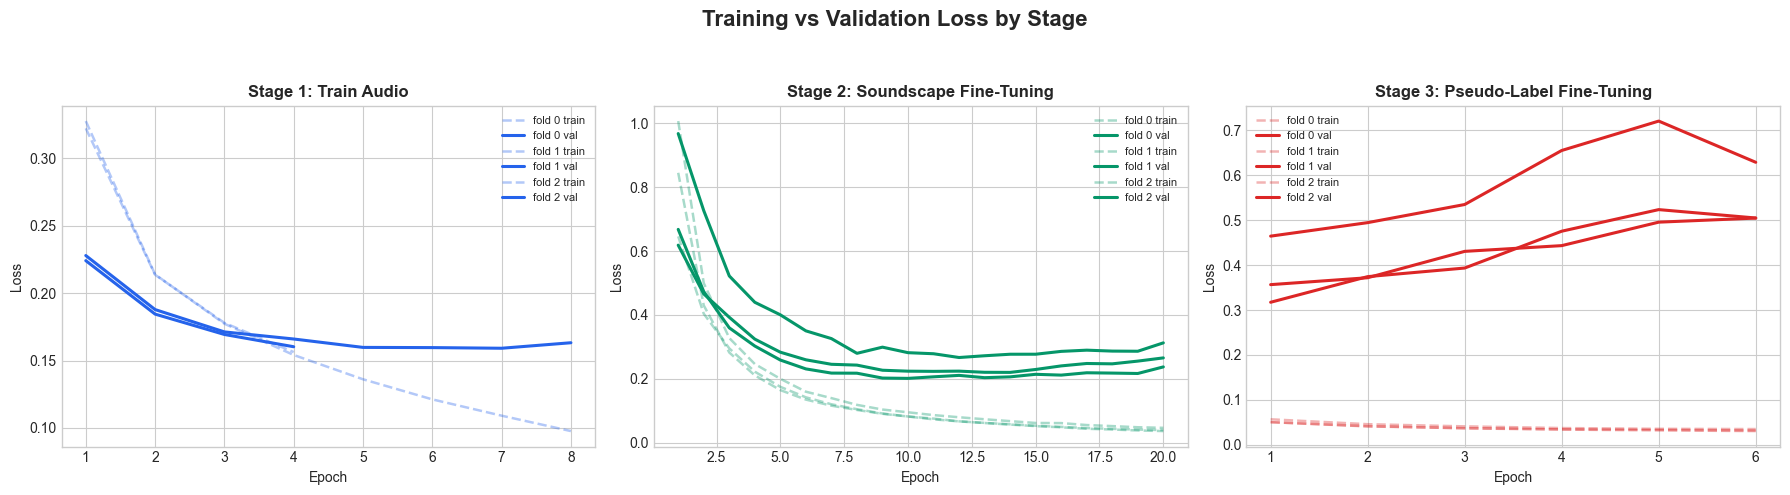

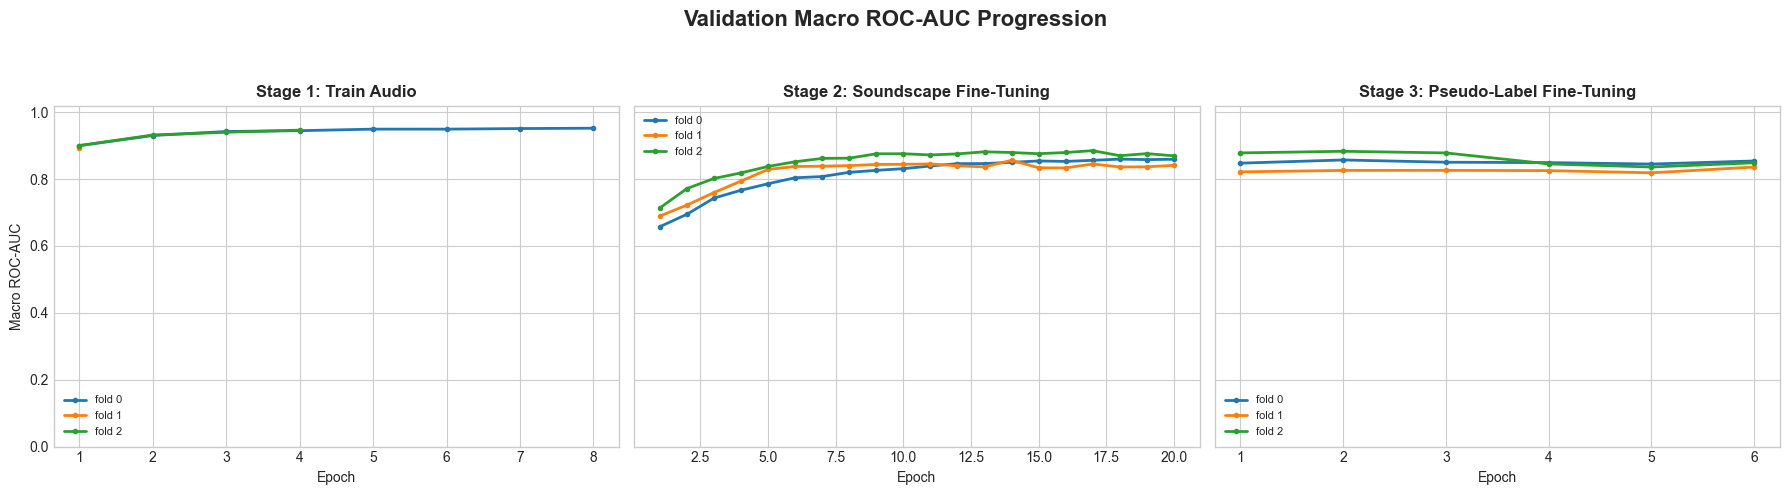

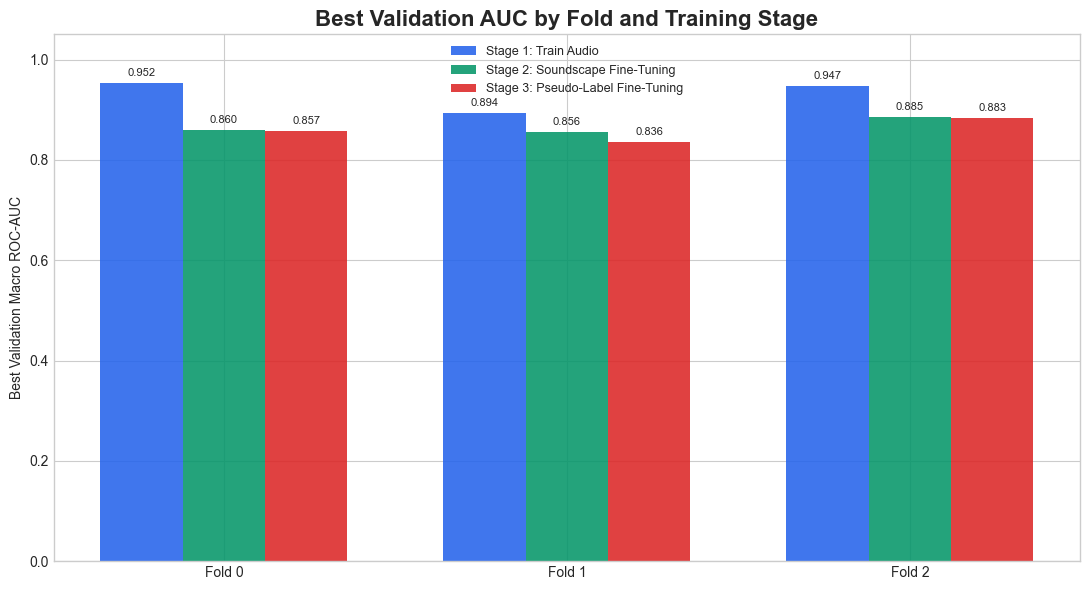

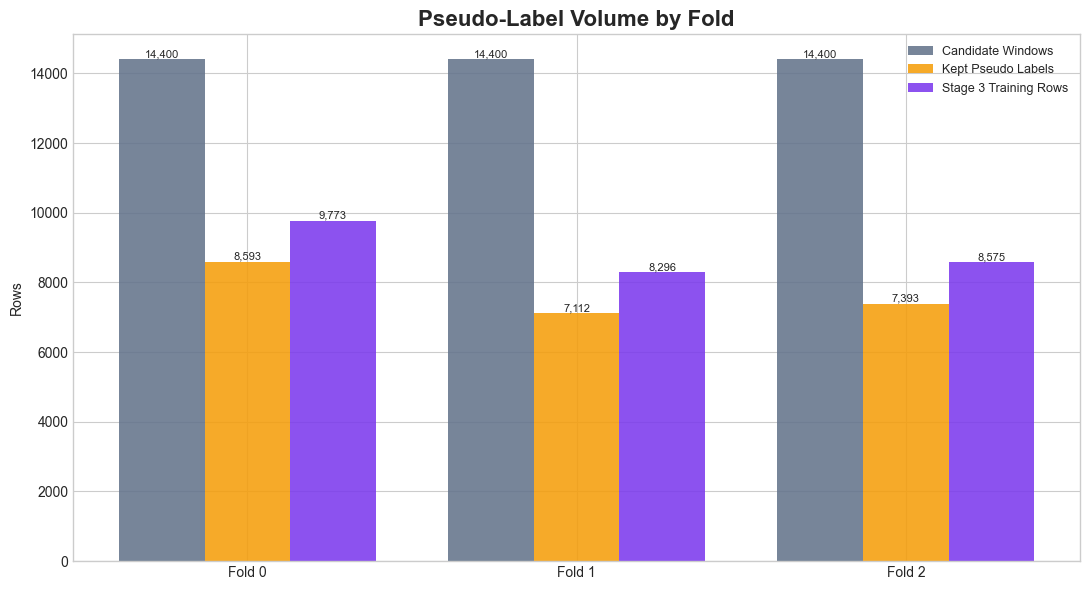

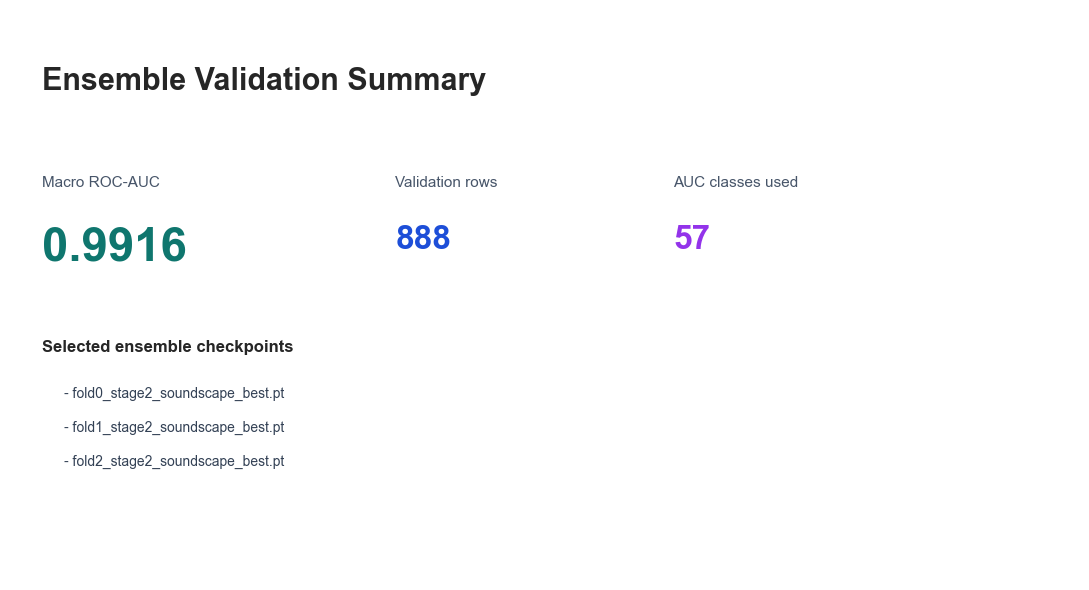

Saved figures to d:\BirdCLEF+\docs\figures


In [13]:
# Regenerate the portfolio figures from saved training/evaluation artifacts.
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd()
STRONG_DIR = PROJECT_DIR / "birdclef_work" / "strong_pipeline"
FIGURE_DIR = PROJECT_DIR / "docs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
stage_order = ["stage1_train_audio", "stage2_soundscape", "stage3_pseudolabel"]
stage_titles = {
    "stage1_train_audio": "Stage 1: Train Audio",
    "stage2_soundscape": "Stage 2: Soundscape Fine-Tuning",
    "stage3_pseudolabel": "Stage 3: Pseudo-Label Fine-Tuning",
}
stage_colors = {
    "stage1_train_audio": "#2563eb",
    "stage2_soundscape": "#059669",
    "stage3_pseudolabel": "#dc2626",
}

def load_training_histories():
    frames = []
    for path in sorted(STRONG_DIR.glob("stage*_fold*_history.csv")):
        df = pd.read_csv(path)
        if len(df):
            df["history_file"] = path.name
            frames.append(df)
    if not frames:
        raise FileNotFoundError("No stage history CSVs found in birdclef_work/strong_pipeline.")
    history = pd.concat(frames, ignore_index=True)
    history["fold"] = history["fold"].astype(int)
    history["epoch"] = history["epoch"].astype(int)
    return history

history = load_training_histories()

# 1. Training vs validation loss curves.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, stage in zip(axes, stage_order):
    part = history[history["stage"] == stage]
    if part.empty:
        ax.set_axis_off()
        continue
    for fold, fold_df in part.groupby("fold"):
        fold_df = fold_df.sort_values("epoch")
        ax.plot(fold_df["epoch"], fold_df["train_loss"], linestyle="--", alpha=0.35, linewidth=1.8, color=stage_colors[stage], label=f"fold {fold} train")
        ax.plot(fold_df["epoch"], fold_df["val_loss"], linewidth=2.2, color=stage_colors[stage], label=f"fold {fold} val")
    ax.set_title(stage_titles[stage], weight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=8)
fig.suptitle("Training vs Validation Loss by Stage", fontsize=16, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(FIGURE_DIR / "training_loss_curves.png", dpi=180, bbox_inches="tight")
plt.show()

# 2. Validation macro ROC-AUC curves.
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, stage in zip(axes, stage_order):
    part = history[history["stage"] == stage]
    if part.empty:
        ax.set_axis_off()
        continue
    for fold, fold_df in part.groupby("fold"):
        fold_df = fold_df.sort_values("epoch")
        ax.plot(fold_df["epoch"], fold_df["val_macro_auc"], marker="o", markersize=3, linewidth=2, label=f"fold {fold}")
    ax.set_title(stage_titles[stage], weight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Macro ROC-AUC")
fig.suptitle("Validation Macro ROC-AUC Progression", fontsize=16, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(FIGURE_DIR / "validation_auc_curves.png", dpi=180, bbox_inches="tight")
plt.show()

# 3. Best validation AUC by fold and training stage.
best_rows = history.loc[history.groupby(["stage", "fold"])["val_macro_auc"].idxmax()]
pivot = best_rows.pivot(index="fold", columns="stage", values="val_macro_auc").reindex(columns=stage_order)
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(pivot.index))
width = 0.24
for i, stage in enumerate(stage_order):
    vals = pivot[stage].values
    bars = ax.bar(x + (i - 1) * width, vals, width=width, label=stage_titles[stage], color=stage_colors[stage], alpha=0.88)
    for bar, val in zip(bars, vals):
        if np.isfinite(val):
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {int(f)}" for f in pivot.index])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Best Validation Macro ROC-AUC")
ax.set_title("Best Validation AUC by Fold and Training Stage", fontsize=16, weight="bold")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "fold_best_auc_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

# 4. Pseudo-label volume by fold.
volume_rows = []
for fold in sorted(history["fold"].unique()):
    candidate_path = STRONG_DIR / f"pseudo_candidates_fold{fold}.csv"
    label_path = STRONG_DIR / f"pseudo_labels_fold{fold}.csv"
    combined_path = STRONG_DIR / f"stage3_combined_fold{fold}.csv"
    volume_rows.append({
        "fold": int(fold),
        "candidate_windows": len(pd.read_csv(candidate_path)) if candidate_path.exists() else 0,
        "pseudo_label_rows": len(pd.read_csv(label_path)) if label_path.exists() else 0,
        "combined_train_rows": len(pd.read_csv(combined_path)) if combined_path.exists() else 0,
    })
volume = pd.DataFrame(volume_rows)
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(volume))
width = 0.26
series = [
    ("candidate_windows", "Candidate Windows", "#64748b"),
    ("pseudo_label_rows", "Kept Pseudo Labels", "#f59e0b"),
    ("combined_train_rows", "Stage 3 Training Rows", "#7c3aed"),
]
for i, (col, label, color) in enumerate(series):
    bars = ax.bar(x + (i - 1) * width, volume[col].values, width=width, label=label, color=color, alpha=0.88)
    for bar, val in zip(bars, volume[col].values):
        ax.text(bar.get_x() + bar.get_width() / 2, val, f"{int(val):,}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {int(f)}" for f in volume["fold"]])
ax.set_ylabel("Rows")
ax.set_title("Pseudo-Label Volume by Fold", fontsize=16, weight="bold")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "pseudo_label_volume.png", dpi=180, bbox_inches="tight")
plt.show()

# 5. Ensemble validation summary card.
metrics_path = STRONG_DIR / "ensemble_validation_metrics.json"
metrics = json.loads(metrics_path.read_text(encoding="utf-8")) if metrics_path.exists() else {}
checkpoint_names = [Path(p).name for p in metrics.get("ensemble_checkpoints", [])]
fig, ax = plt.subplots(figsize=(11, 6))
ax.axis("off")
ax.text(0.03, 0.86, "Ensemble Validation Summary", fontsize=22, weight="bold", transform=ax.transAxes)
ax.text(0.03, 0.69, "Macro ROC-AUC", fontsize=11, color="#475569", transform=ax.transAxes)
ax.text(0.03, 0.56, f"{metrics.get('macro_auc_skip_empty', float('nan')):.4f}", fontsize=34, weight="bold", color="#0f766e", transform=ax.transAxes)
ax.text(0.36, 0.69, "Validation rows", fontsize=11, color="#475569", transform=ax.transAxes)
ax.text(0.36, 0.58, f"{metrics.get('rows', 0):,}", fontsize=24, weight="bold", color="#1d4ed8", transform=ax.transAxes)
ax.text(0.62, 0.69, "AUC classes used", fontsize=11, color="#475569", transform=ax.transAxes)
ax.text(0.62, 0.58, f"{metrics.get('auc_classes_used', 0):,}", fontsize=24, weight="bold", color="#9333ea", transform=ax.transAxes)
ax.text(0.03, 0.40, "Selected ensemble checkpoints", fontsize=12, weight="bold", transform=ax.transAxes)
for i, name in enumerate(checkpoint_names[:6]):
    ax.text(0.05, 0.32 - i * 0.06, f"- {name}", fontsize=10, color="#334155", transform=ax.transAxes)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "ensemble_validation_summary.png", dpi=180, bbox_inches="tight")
plt.show()

print("Saved figures to", FIGURE_DIR)
